In [27]:
#########################
# Include Headers
#########################

using LinearAlgebra
using Arpack
using CairoMakie


# Dependencies
include("../.header/.src/circuit/brickwall.jl")
include("../.header/.src/circuit/abanin.jl")

# Extras
include("../.header/.src/plotmods/colorschemes_mods.jl")
include("../.header/.src/random_matrices/random_matrices.jl")
include("../.header/.src/measurements/projectors.jl")
include("../.header/.src/info_lattice/info_lattice.jl")
include("../.header/.src/lazadires_diagram/lazadires_diagram.jl")




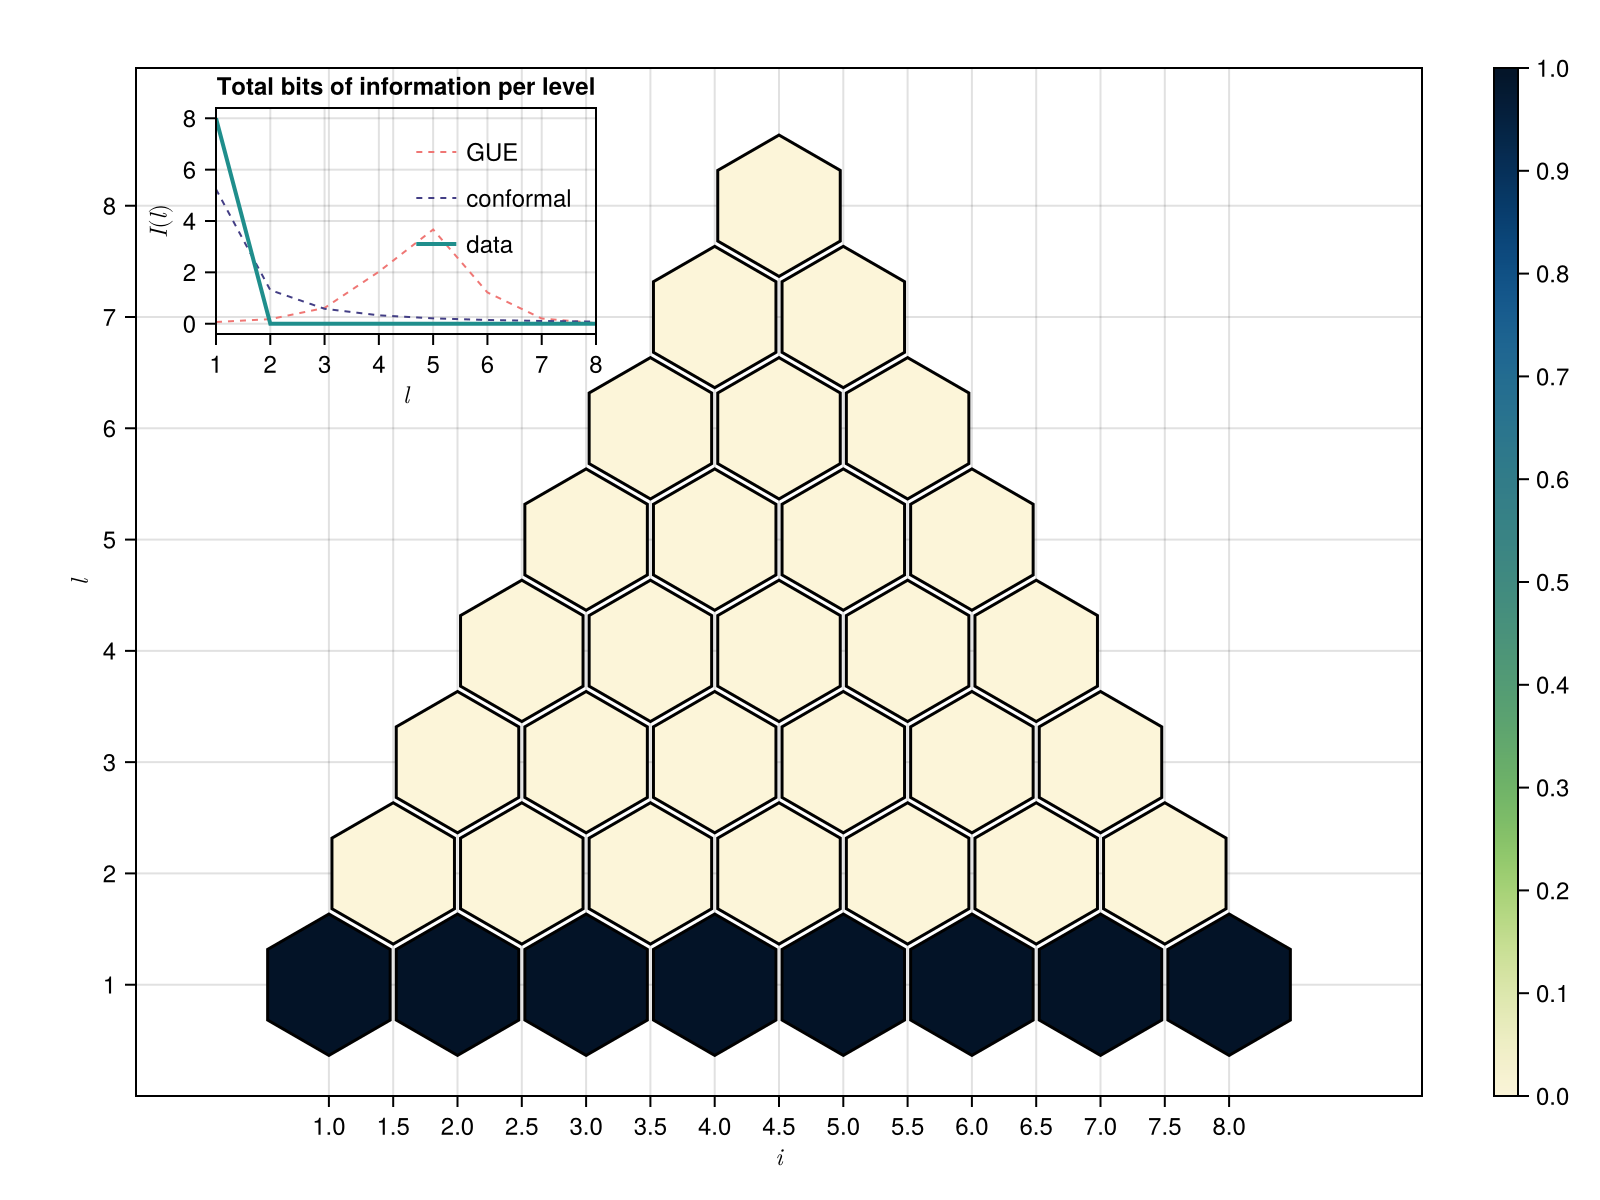

In [3]:
# Test: brickwall_abanin

L=8
theta=0.0
h=rand(L)*2*pi;
J=rand(L-1)*pi;


FU=brickwall_abanin(L, theta, h, J)
A=brickwall(FU);

draw_info_lattice(info_lattice(A))


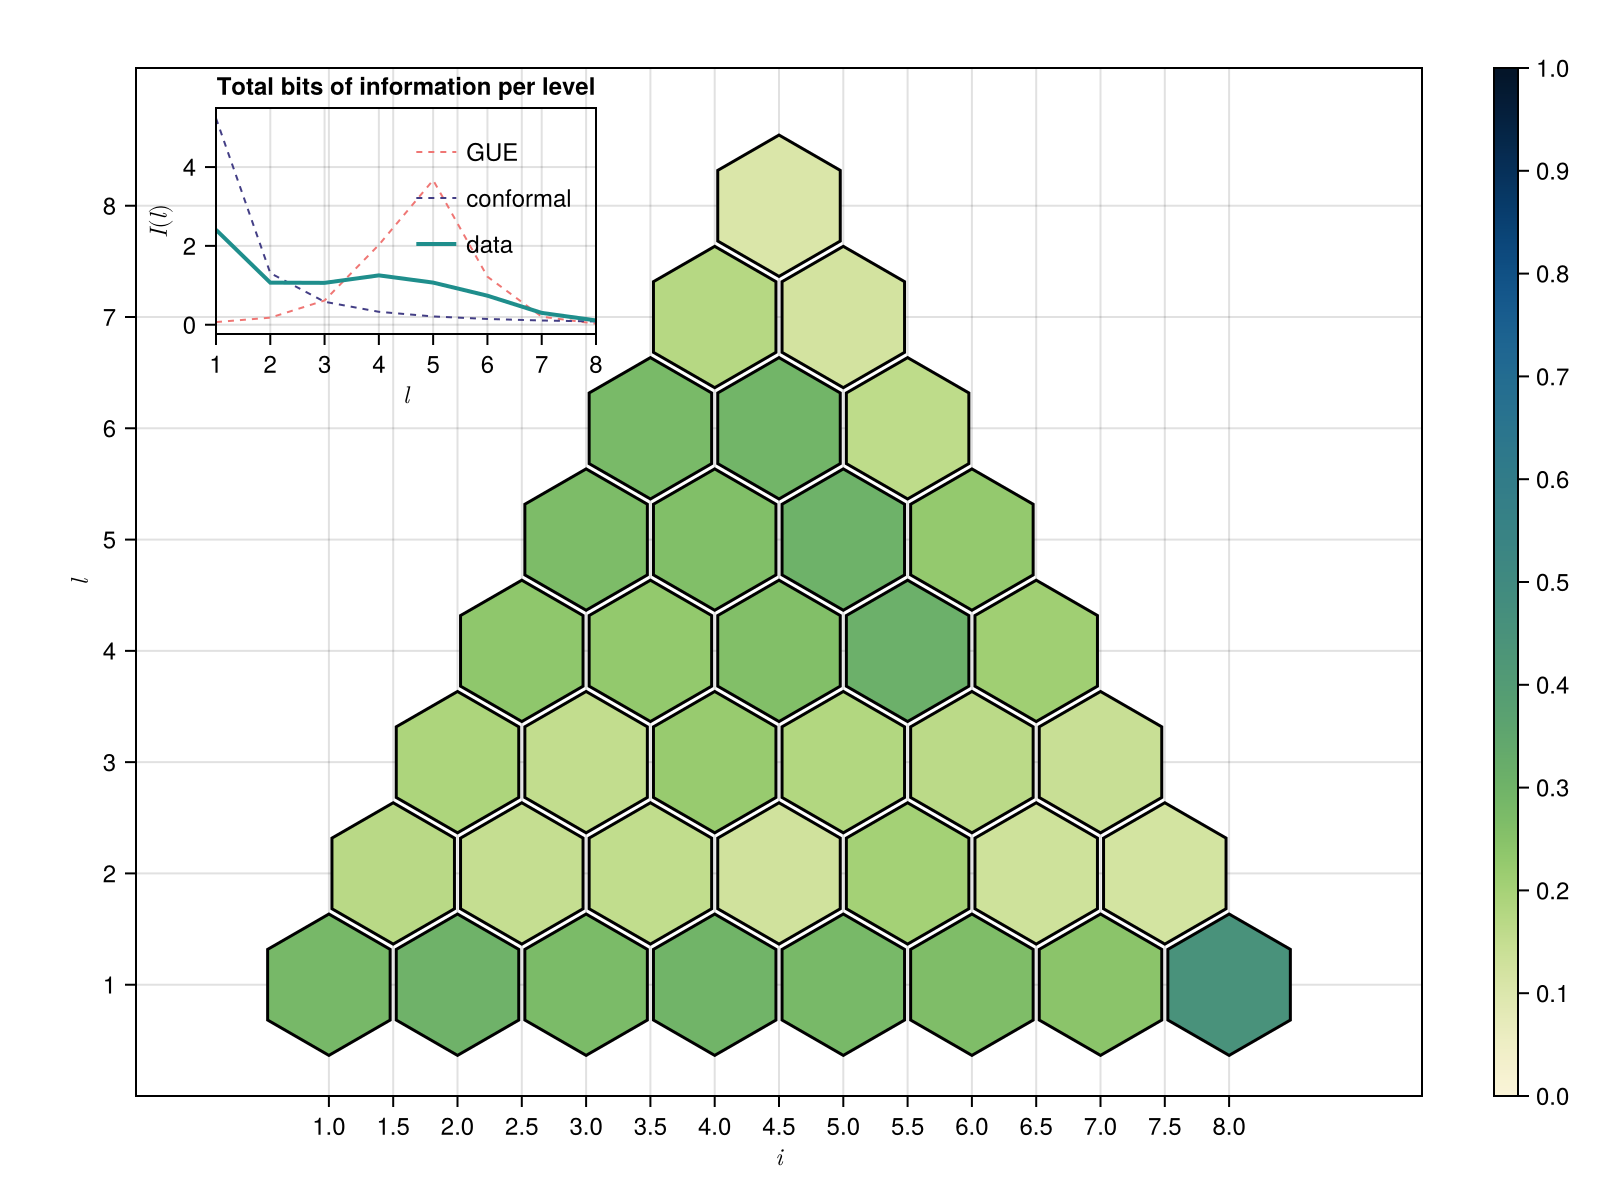

In [4]:
# Test: The circuit:


L=8
theta=0.2
h=rand(L)*2*pi;
J=rand(L-1)*pi;


A=circuit_abanin(L, theta, h, J);

draw_info_lattice(info_lattice(A))

Testing the parameters of the Paper:

from PRL 114, 140401 (2015)

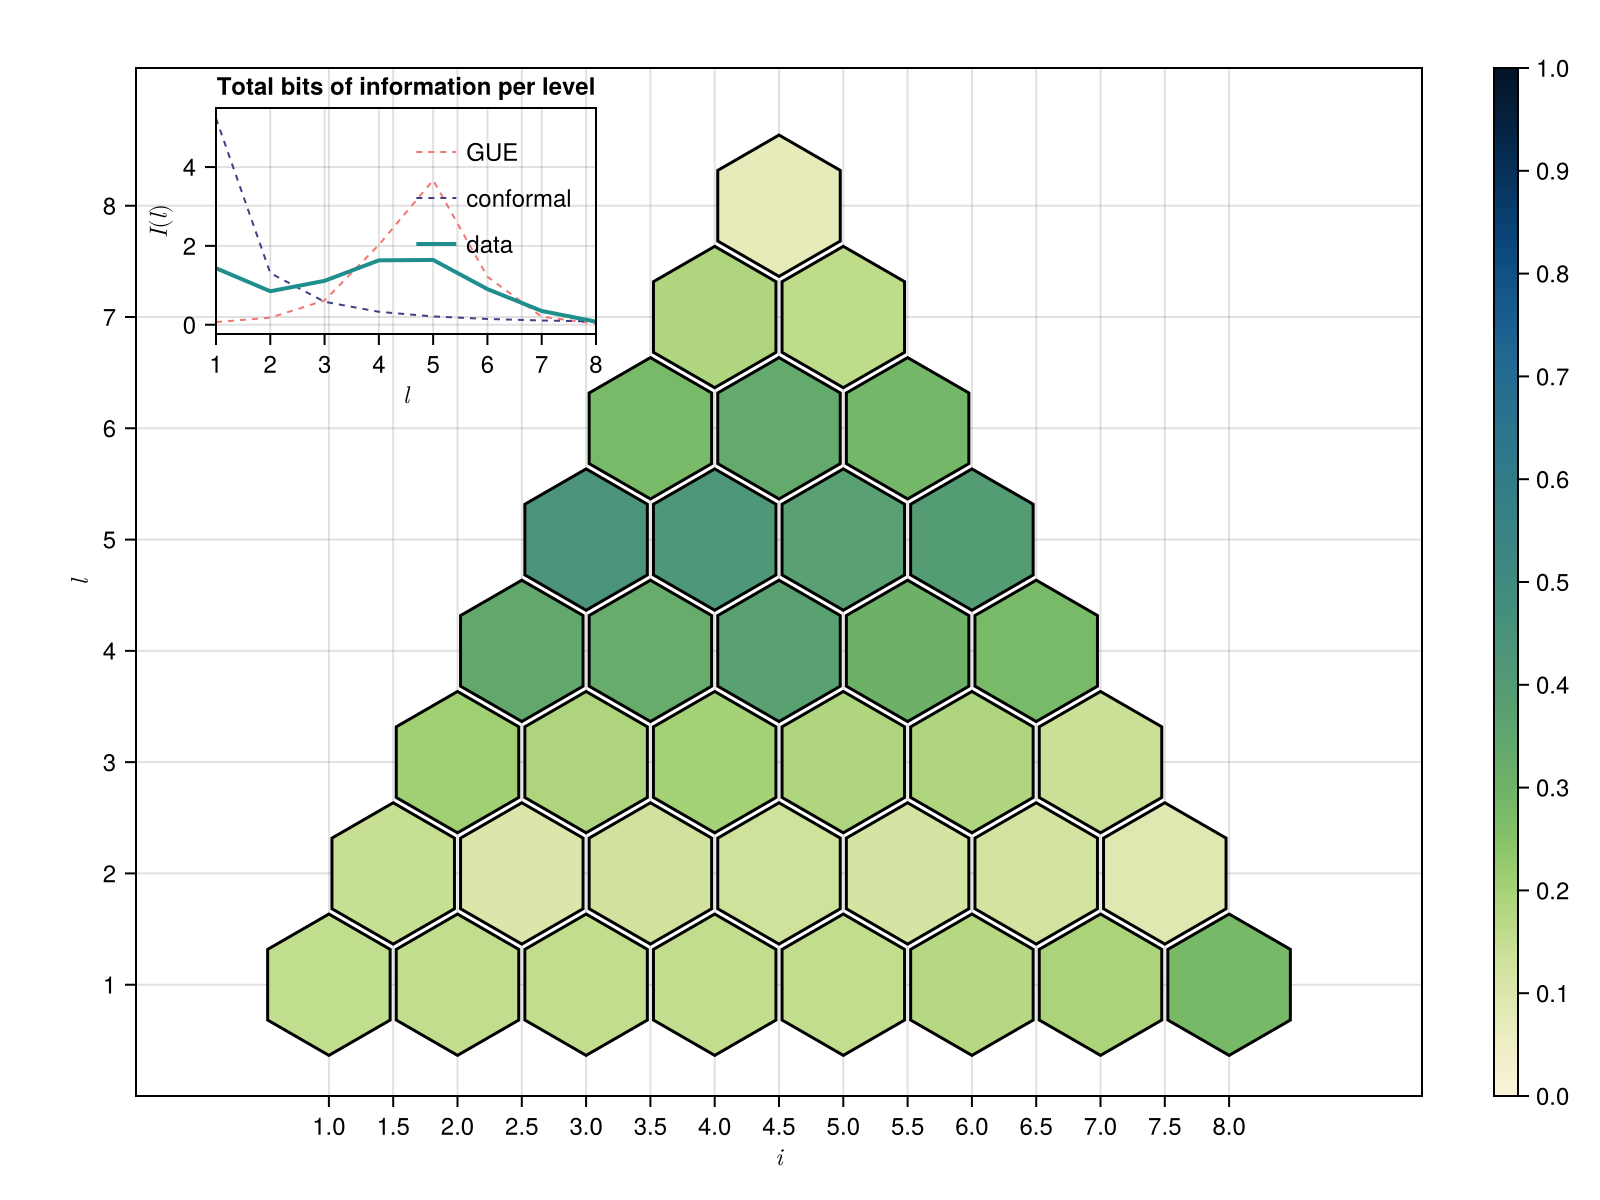

In [7]:
################################
# Tests: Multiple Dispatch variations:
#################################


# implicitly drawing Background Disorders h, J

L=8
theta=1.0

A=circuit_abanin(L, theta);
draw_info_lattice(info_lattice(A))



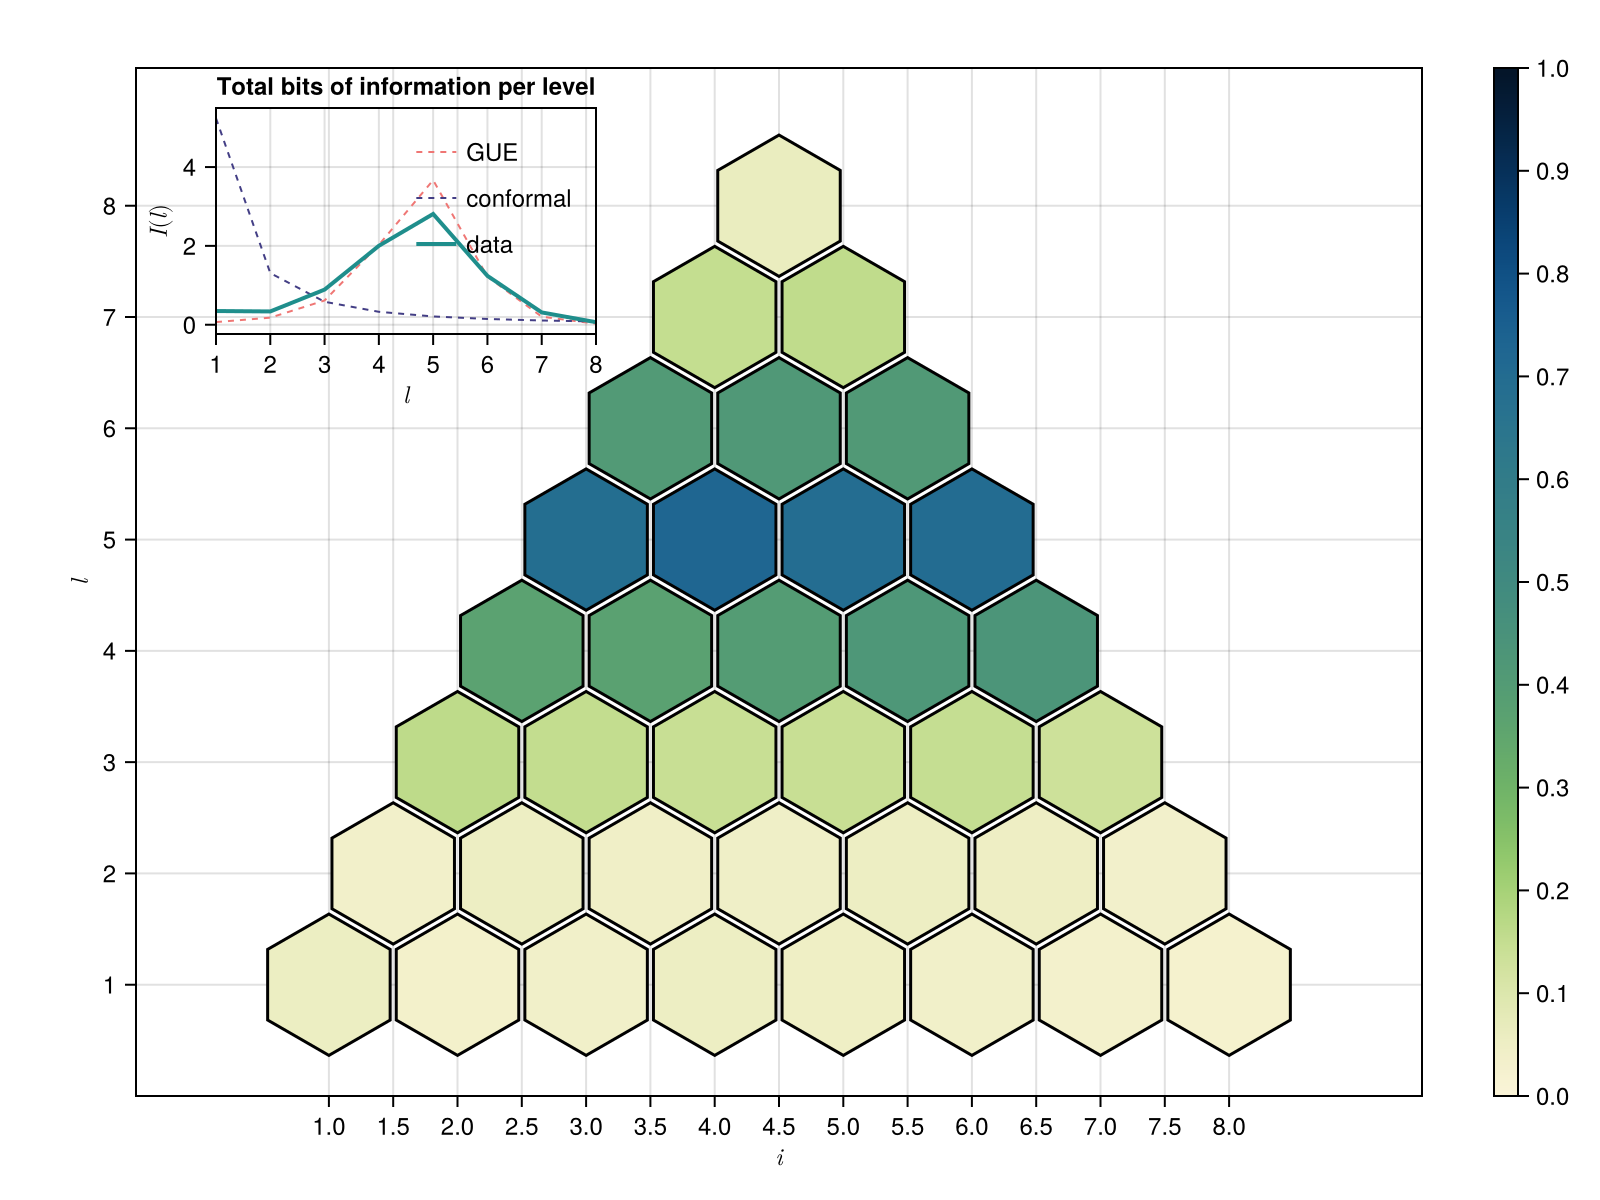

In [8]:
################################
# Tests: ETH?
#################################


# implicitly drawing Background Disorders h, J

L=8
theta=4.0

A=circuit_abanin(L, theta);
draw_info_lattice(info_lattice(A))



Tests with other parameters:

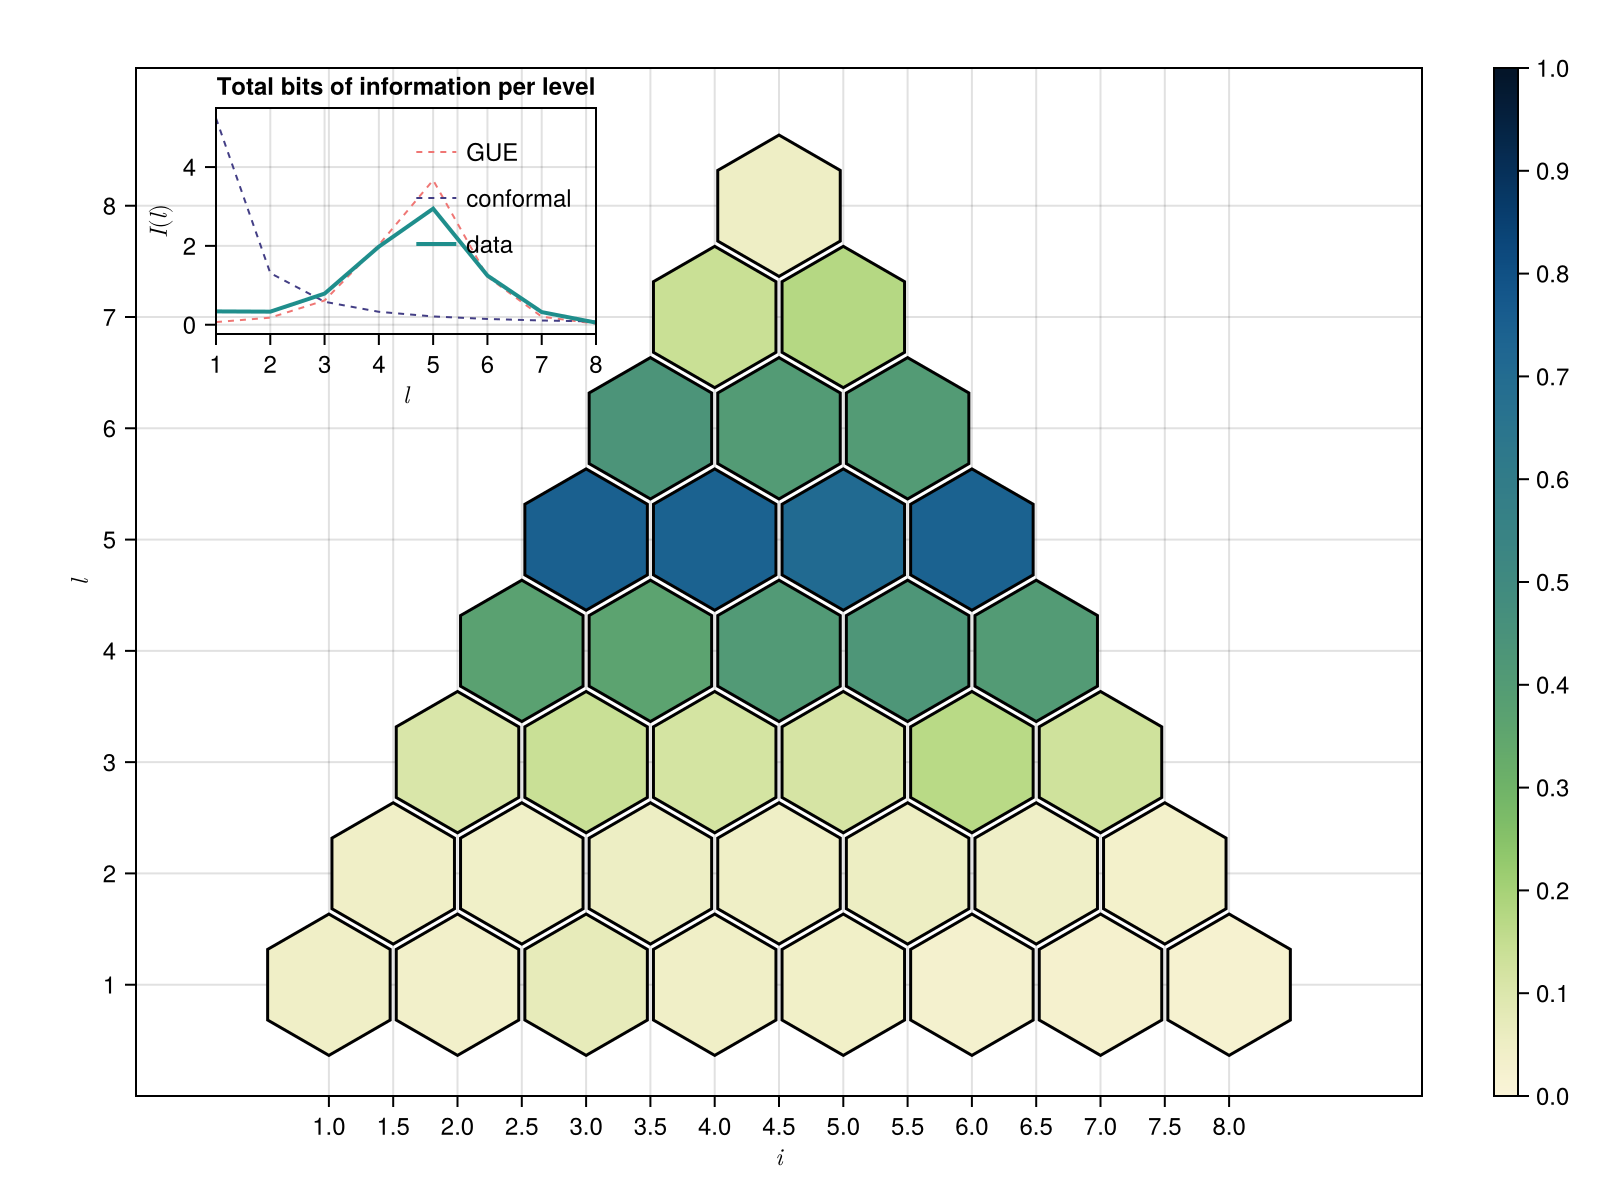

In [48]:
################################
# Tests: Taking h between [0,2pi]
#################################


# implicitly drawing Background Disorders h, J as per paper

L=8
h=rand(L)*2*pi;
J=fill(0.25, (L-1));


theta=4.0

theta=theta/4
A=circuit_abanin(L, theta, h, J);

draw_info_lattice(info_lattice(A))




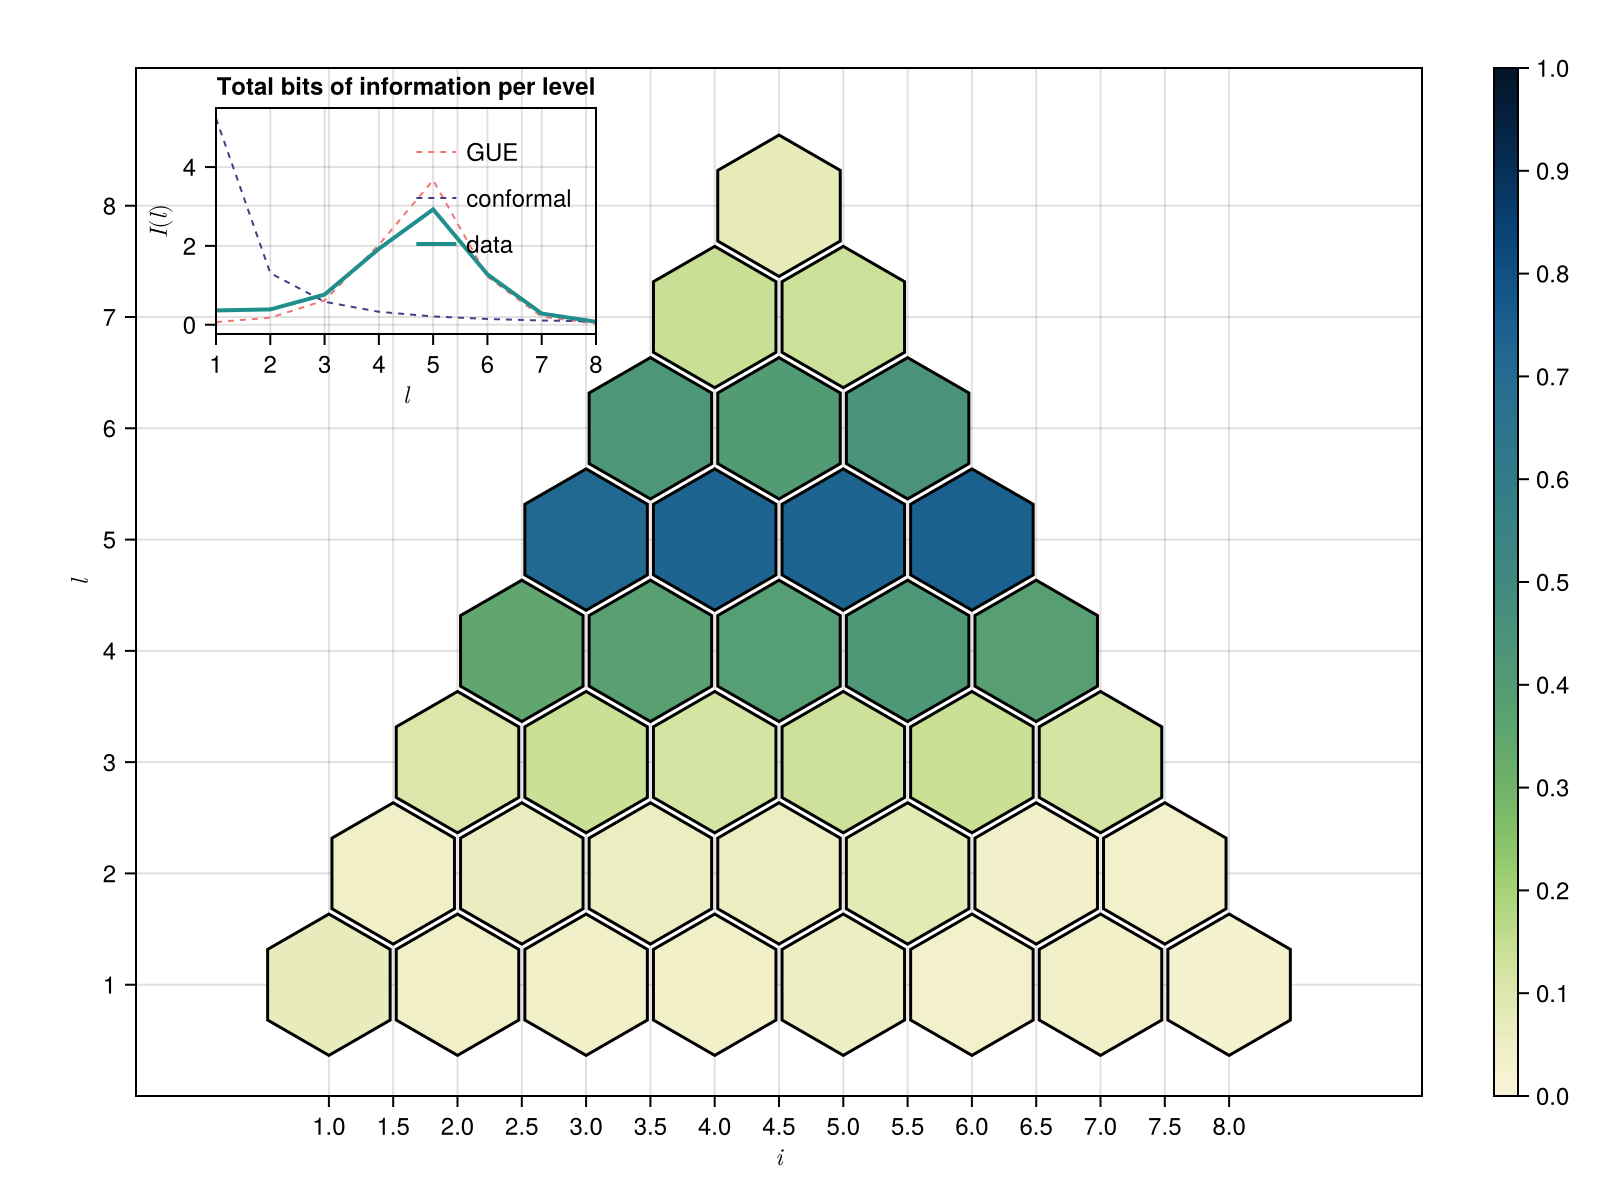

In [13]:
################################
# Tests: Taking h between [0,2pi]
# J=1.0; Theta=0.5
#################################


# implicitly drawing Background Disorders h, J as per paper

L=8
h=rand(L)*2*pi;
J=fill(1.0, (L-1));


theta=2.0

theta=theta/2
A=circuit_abanin(L, theta, h, J);

draw_info_lattice(info_lattice(A))




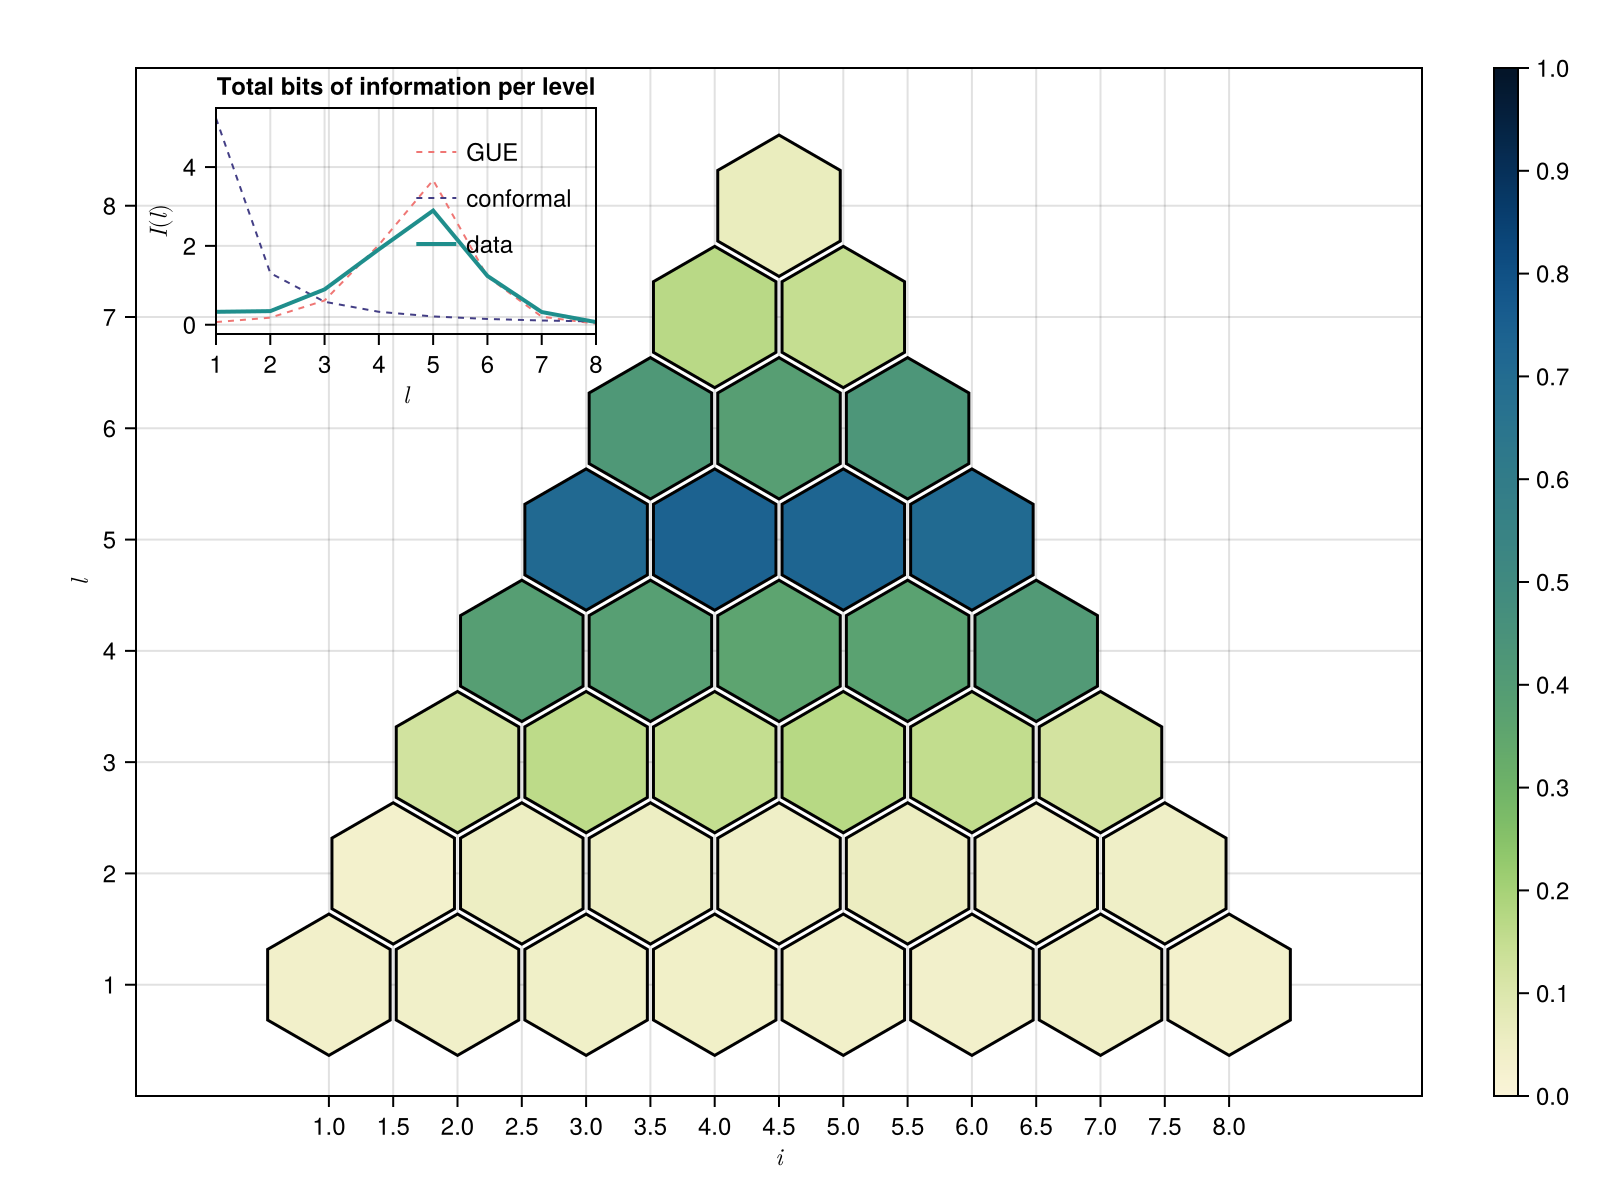

In [15]:
################################
# Tests: Taking h between [0,2pi]
# J=1.0, Theta=0.5
#################################


include("../.header/.src/circuit/time_crystals.jl")

L=8
h=rand(L)*2*pi;
J=fill(1.0, (L-1));
epsilon=1.0

theta=2.0

#theta=theta/2                      # To account for the factor diffference in abanin.jl   ln:69
A=circuit_dtc(L, theta, epsilon, h, J);

draw_info_lattice(info_lattice(A))

In [ ]:
eigen_statistics:

In [30]:
include("../.header/.src/eigen_statistics/eigen_statistics.jl")

L=8
h=rand(L)*2*pi;
J=fill(1.0, (L-1));
epsilon=1.0

theta=2.0

#theta=theta/2                      # To account for the factor diffference in abanin.jl   ln:69
A=circuit_dtc(L, theta, epsilon, h, J);

eigvals, eigvecs = eigen(A)
MeanLevelSpacingRatio(eigvals)

0.40809961596227684

In [52]:

L=8
theta=4.0

A=circuit_abanin(L, theta);


eigvals, eigvecs = eigen(A)
MeanLevelSpacingRatio(eigvals)

0.39937983159283247

In [50]:
ind_odd=0
ind_even=0;

eigs_even=[]
eigs_odd=[]

for i in 1:length(parind)
    if parind[i]>0
        #ind_even=ind_even+1
        push!(eigs_even, eigvals[i])
    end
    if parind[i]<0
        #ind_odd=ind_odd+1
        push!(eigs_odd, eigvals[i])
    end

    #print("$(ind_odd), $(ind_even), \n")
end
    

MeanLevelSpacingRatio(eigs_even)

0.4179080906731046

In [51]:

MeanLevelSpacingRatio(eigs_odd)

0.4185043687605066

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Ritam\.julia\packages\Makie\4JW9B\src\scenes.jl:264


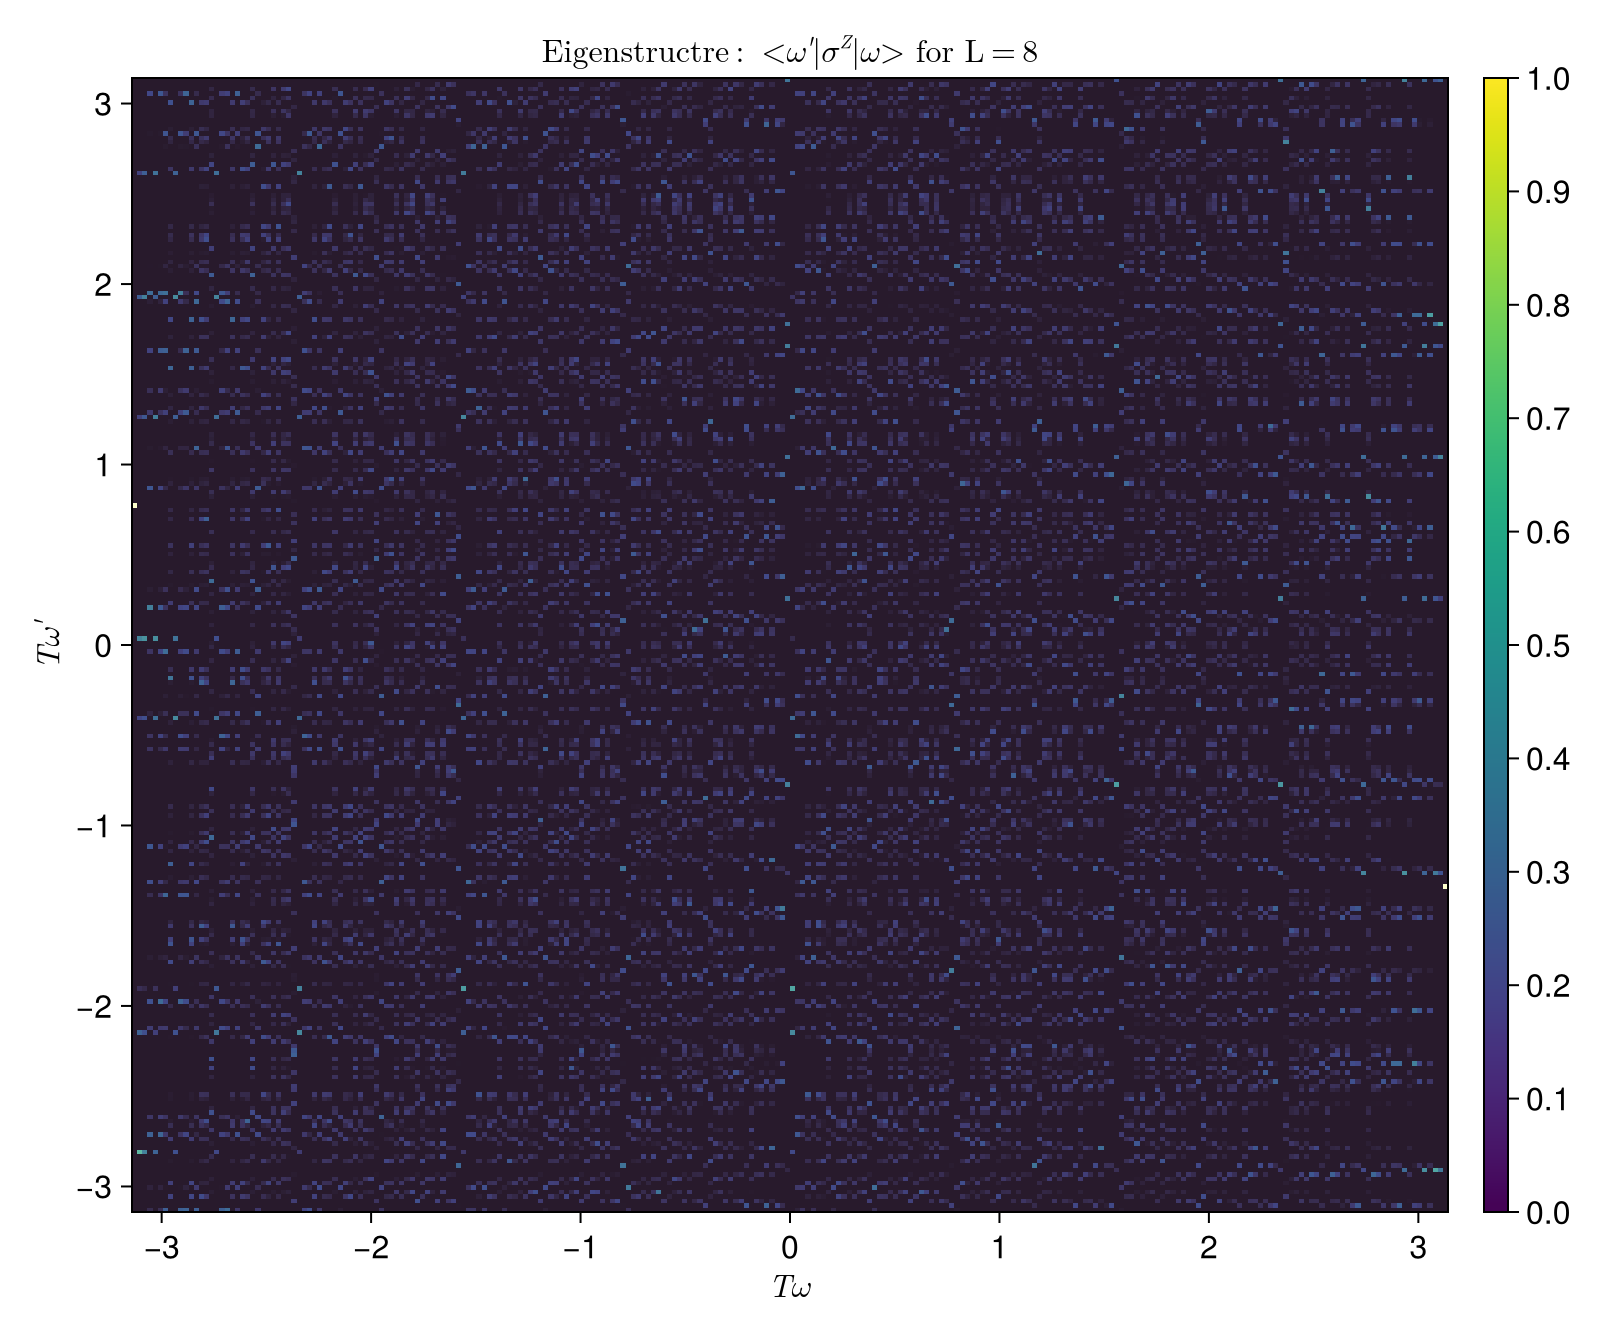

In [53]:
LazadiresDiagramPlot(abs.(eigvecs))